# Gleich und Wechselstrombrücken

In [16]:
import uncertainties as unc
from uncertainties import ufloat
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 18}

matplotlib.rc('font', **font)

## Geräte Parameter

### 1.1 Berechnungen

Näherungsformel GLeichung 2.5. Widerstandsinkrement R_1 tauschen mit R_4 da $R_1R_4 = R_2R_3$ gilt



Abgleichbedingung

$$ 
\frac{R_1}{R_2} = \frac{R_3}{R_4}, \quad \frac{R_2}{R_1} = ratio \\
R_3 = R_4 \cdot ratio, \quad R_2 = \frac{R_1}{ratio}
$$

In [17]:
# Gegeben
UH = 3
# Zu Messen
deltaU = -30e-6
deltaR4 = 1
R1 = ufloat(3472,32) # Messergebnis +/- Garantiefehler im MB


In [18]:
def calcR(ratio):
    R4 = -(deltaR4 * UH) / (deltaU * (1+1/ratio)*(1+ratio))
    R3 = R4/ratio
    R2 = R1*ratio
    return {
        "Ratio": ratio,
        "R1": R1,
        "R2": R2,
        "R3": R3,
        "R4": R4
    }

data = [calcR(r) for r in [0.5, 1, 2]]
df1 = pd.DataFrame(data, columns=['Ratio', 'R1' ,'R2', 'R3', 'R4'])
print(df1.to_latex(
    index=False,
    formatters={
        "Ratio": "${:.1f}$".format,
        "R1": "${:.2uS}$".format,
        "R2": "${:.2uS}$".format,
        "R3": "${:.0f}$".format,
        "R4": "${:.0f}$".format
        }
    ))
df1


\begin{tabular}{rllrr}
\toprule
Ratio & R1 & R2 & R3 & R4 \\
\midrule
$0.5$ & $3472(32)$ & $1736(16)$ & $44444$ & $22222$ \\
$1.0$ & $3472(32)$ & $3472(32)$ & $25000$ & $25000$ \\
$2.0$ & $3472(32)$ & $6944(64)$ & $11111$ & $22222$ \\
\bottomrule
\end{tabular}



,Ratio,R1,R2,R3,R4
0,0.5,3472+/-32,1736+/-16,44444.444444,22222.222222
1,1.0,3472+/-32,3472+/-32,25000.000000,25000.000000
2,2.0,3472+/-32,(6.94+/-0.06)e+03,11111.111111,22222.222222


### 1.2 Berechnungen

R2 R3 Grob,
R4 fein,
R1 berechnen

In [19]:
def rd(a):
    return a/np.sqrt(3)
def ird(u):
    return u*np.sqrt(3)

def calcR(ratio, R2, R3, R4):
    R1 = R2*R3/R4
    return {
        "Ratio": ratio,
        "R2": R2,
        "R3": R3,
        "R4": R4,
        "R1": R1
    }

table = [
    (0.5,ufloat(2200, rd(22)),  ufloat(47000,rd(470)), ufloat(29690,rd(296.9+0.025))),
    (0.5,ufloat(2200, rd(22)),  ufloat(22000,rd(220)), ufloat(13870,rd(138.7+0.025))),
    (1,  ufloat(4700, rd(47)),  ufloat(22000,rd(220)), ufloat(29680,rd(296.8+0.025))),
    (1,  ufloat(4700, rd(47)),  ufloat(10000,rd(100)), ufloat(13510,rd(135.1+0.025))),
    (2,  ufloat(10000,rd(100)), ufloat(10000,rd(100)), ufloat(29050,rd(290.5+0.025))),
    (2,  ufloat(10000,rd(100)), ufloat(4700, rd(47)),  ufloat(13600,rd(136+0.025)))
]
data = [ calcR(r,R2,R3,R4) for r,R2,R3,R4 in table]
df2 = pd.DataFrame(data, columns=['Ratio' ,'R2', 'R3', 'R4', 'R1'])
print(df2.to_latex(
    float_format="${:.1f}$".format,
    formatters={
        "R1": "${:.3uS}$".format,
        "R2": "${:.3uS}$".format,
        "R3": "${:.3uS}$".format,
        "R4": "${:.3uS}$".format
        }
    ))
df2

\begin{tabular}{lrllll}
\toprule
 & Ratio & R2 & R3 & R4 & R1 \\
\midrule
0 & $0.5$ & $2200.0(12.7)$ & $47000(271)$ & $29690(171)$ & $3482.7(34.8)$ \\
1 & $0.5$ & $2200.0(12.7)$ & $22000(127)$ & $13870.0(80.1)$ & $3489.5(34.9)$ \\
2 & $1.0$ & $4700.0(27.1)$ & $22000(127)$ & $29680(171)$ & $3483.8(34.8)$ \\
3 & $1.0$ & $4700.0(27.1)$ & $10000.0(57.7)$ & $13510.0(78.0)$ & $3478.9(34.8)$ \\
4 & $2.0$ & $10000.0(57.7)$ & $10000.0(57.7)$ & $29050(168)$ & $3442.3(34.4)$ \\
5 & $2.0$ & $10000.0(57.7)$ & $4700.0(27.1)$ & $13600.0(78.5)$ & $3455.9(34.6)$ \\
\bottomrule
\end{tabular}



,Ratio,R2,R3,R4,R1
0,0.5,2200+/-13,(4.700+/-0.027)e+04,(2.969+/-0.017)e+04,3483+/-35
1,0.5,2200+/-13,(2.200+/-0.013)e+04,(1.387+/-0.008)e+04,3490+/-35
2,1.0,4700+/-27,(2.200+/-0.013)e+04,(2.968+/-0.017)e+04,3484+/-35
3,1.0,4700+/-27,(1.000+/-0.006)e+04,(1.351+/-0.008)e+04,3479+/-35
4,2.0,(1.000+/-0.006)e+04,(1.000+/-0.006)e+04,(2.905+/-0.017)e+04,3442+/-34
5,2.0,(1.000+/-0.006)e+04,4700+/-27,(1.360+/-0.008)e+04,3456+/-35


In [20]:
def calcR(ratio, R2, R3, R4):
    R2 = R2 + 0.4
    R3 = R3 + 0.4
    R4 = R4 + 0.4
    R1 = R2*R3/R4 - 0.4
    return {
        "R1": R1
    }
data = [ calcR(r,R2,R3,R4) for r,R2,R3,R4 in table]
df2b = pd.DataFrame(data, columns=['R1'])
print(df2b.to_latex(
    formatters={
        "R1": "{:.3uS}".format,
        }
    ))
df2b

\begin{tabular}{ll}
\toprule
 & R1 \\
\midrule
0 & 3482.9(34.8) \\
1 & 3489.7(34.9) \\
2 & 3483.7(34.8) \\
3 & 3478.8(34.8) \\
4 & 3442.2(34.4) \\
5 & 3455.8(34.6) \\
\bottomrule
\end{tabular}



,R1
0,3483+/-35
1,3490+/-35
2,3484+/-35
3,3479+/-35
4,3442+/-34
5,3456+/-35


In [21]:
R1 = df2b['R1']
R1_nom = [r.n for r in R1]
R1_unc = [r.s for r in R1]
mean = np.mean(R1_nom)
u_b = np.sqrt(np.sum(np.array(R1_unc)**2)/len(R1_unc)**2)
std = np.std(R1_nom, ddof=1)
u_a = 7.68
u_c = np.sqrt(u_a**2 + u_b**2)
u_c, u_c*2.57, u_b

(np.float64(16.123459181387766),
 np.float64(41.43729009616656),
 np.float64(14.176866225434923))

### 1.3 Empfindlichkeit

In [22]:
deltaR1 = 10.1 # 5...10 Ohm
U0min = 30e-6 # Kleinst mögliche spannungsänderung -> Auflösung MB


#### Berechnung mit $U_0$

Diese Annäherung gilt für sehr kleine Abweichungen
$$
E = \frac{\partial U_0}{\partial\frac{\Delta R_1}{R_1}} \approx \frac{U_0}{\frac{\Delta R_1}{R_1}}
$$

absolut Kleinste Widerstandsänderung, die am Messgerät erkannt wird

$$
\Delta R_{1,\min} = \frac{\Delta R_1\cdot U_{0,\min}}{U_0}
$$

relativ Kleinste Widerstandsänderung, die am Messgerät erkannt wird

$$
\frac{\Delta R_{1,min}}{R_1} = \frac{\Delta R_1\cdot U_{0,\min}}{U_0\cdot R_1}
$$

In [23]:
# Zu Messen
U0 = [
	ufloat(-2.2e-3, -2.2e-3*0.0005+3*10e-6),
	ufloat(-2.5e-3, -2.3e-3*0.0005+3*10e-6),
	ufloat(-1.6e-3, -1.6e-3*0.0005+3*10e-6),
]

# Berechnung
relR1 = deltaR1/df2["R1"][[0,2,4]]
E = U0/relR1
deltaR1min = [deltaR1*U0min/u for u in U0]
relDeltaR1min = deltaR1min/df2["R1"][[0,2,4]]

data = {
	"U0": U0,
    "E": E,
    "deltaR1min": deltaR1min,
    "relDeltaR1min": relDeltaR1min
}

df3 = pd.DataFrame(data, columns=['U0', 'E', 'deltaR1min', 'relDeltaR1min'])
print(df3.to_latex(
    float_format="{:.2f}".format,
    formatters={
		"U0": "{:.1uS}".format,
        "E": "{:.2uS}".format,
        "deltaR1min": "{:.2uS}".format,
        "relDeltaR1min": "{:.2uS}".format,
        }
    ))
df3

\begin{tabular}{lllll}
\toprule
 & U0 & E & deltaR1min & relDeltaR1min \\
\midrule
0 & -0.00220(3) & -0.759(13) & -0.1377(18) & -3.955(65)e-05 \\
2 & -0.00250(3) & -0.862(13) & -0.1212(14) & -3.479(53)e-05 \\
4 & -0.00160(3) & -0.545(11) & -0.1894(35) & -5.50(11)e-05 \\
\bottomrule
\end{tabular}



,U0,E,deltaR1min,relDeltaR1min
0,-0.002200+/-0.000029,-0.759+/-0.013,-0.1377+/-0.0018,(-3.95+/-0.07)e-05
2,-0.002500+/-0.000029,-0.862+/-0.013,-0.1212+/-0.0014,(-3.48+/-0.05)e-05
4,-0.001600+/-0.000029,-0.545+/-0.011,-0.1894+/-0.0035,(-5.50+/-0.11)e-05


#### Berechnung aus Brückendaten

In [24]:
Uh = 3
R1 = df2["R1"][[0,2,4]]
R2 = df2["R2"][[0,2,4]]
R3 = df2["R3"][[0,2,4]]
R4 = df2["R4"][[0,2,4]]

E = -Uh / ((1+R2/R1)*(1+R3/R4))
relDeltaR1min = U0min / E
deltaR1min = R1 * U0min / E

data = {
	"E": E,
	"deltaR1min": deltaR1min,
	"relDeltaR1min": relDeltaR1min
}
df4 = pd.DataFrame(data, columns=['E', 'deltaR1min', 'relDeltaR1min'])
print(df4.to_latex(
	float_format="{:.2f}".format,
	formatters={
		"E": "{:.2uS}".format,
		"deltaR1min": "{:.2uS}".format,
		"relDeltaR1min": "{:.2uS}".format,
		}
	))
df4

\begin{tabular}{llll}
\toprule
 & E & deltaR1min & relDeltaR1min \\
\midrule
0 & -0.7118(13) & -0.1468(17) & -4.2147(78)e-05 \\
2 & -0.73344(89) & -0.1425(13) & -4.0903(50)e-05 \\
4 & -0.5715(23) & -0.1807(13) & -5.249(21)e-05 \\
\bottomrule
\end{tabular}



,E,deltaR1min,relDeltaR1min
0,-0.7118+/-0.0013,-0.1468+/-0.0017,(-4.215+/-0.008)e-05
2,-0.7334+/-0.0009,-0.1425+/-0.0013,(-4.090+/-0.005)e-05
4,-0.5715+/-0.0023,-0.1807+/-0.0013,(-5.249+/-0.021)e-05


### Nichtlinearität Ausschlaginstrument

In [25]:
R = 1000
Uh = 3

def U0(dR):
    return Uh/2 * dR / (2*R+dR)

deltaR = np.array([-900, -780, -530, 0, 1200, 3700, 9000])
U0set = U0(deltaR)
data = {
    'R2': deltaR + R,
    'dR': deltaR,
    'U0': U0set
}
df5 = pd.DataFrame(data, columns=['R2', 'dR', 'U0'])
print(df5.to_latex(
        index=False,
        formatters={
           "R2": "${:}$".format,
           "dR": "${:}$".format,
           "U0": "${:.3f}$".format,
        }
    ))

\begin{tabular}{rrr}
\toprule
R2 & dR & U0 \\
\midrule
$100$ & $-900$ & $-1.227$ \\
$220$ & $-780$ & $-0.959$ \\
$470$ & $-530$ & $-0.541$ \\
$1000$ & $0$ & $0.000$ \\
$2200$ & $1200$ & $0.562$ \\
$4700$ & $3700$ & $0.974$ \\
$10000$ & $9000$ & $1.227$ \\
\bottomrule
\end{tabular}



In [26]:
dRcont = np.arange(-900, 9000)
U0cont = U0(dRcont)
U0meas = np.array([ -1.200, -0.937, -0.529, 0.000, 0.552, 0.956, 1.207 ])

In [27]:
import sympy as smp
dr, uh, r = smp.symbols('dR U_H R')
k = uh/2*smp.diff(dr/(2*r+dr), dr)
t = k.subs(dr, 0).subs(uh, Uh).subs(r, 1000)
k

U_H*(-dR/(2*R + dR)**2 + 1/(2*R + dR))/2

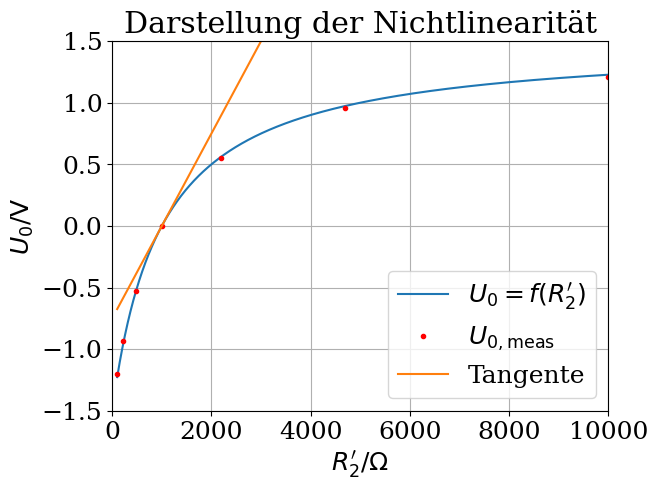

In [28]:
plt.plot(dRcont+1000, U0cont, label="$U_0 = f(R_2')$")
plt.plot(deltaR+1000, U0meas, '.', color="red", label="$U_{0,\\text{meas}}$")
plt.plot(dRcont+1000, dRcont*t, label="Tangente")
plt.xlim(0,10000)
plt.ylim(-1.5,1.5)
plt.xlabel('$R_2\' / \\Omega$')
plt.ylabel('$U_0 / \\mathrm{V}$')
plt.legend(loc="lower right")
plt.title("Darstellung der Nichtlinearität")
plt.grid()
plt.savefig("./latex/images/nonLin.png")
plt.show()